In [19]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('Dataset-SA.csv')
df_subset = df.head(4000)
df_subset

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral
...,...,...,...,...,...,...
3995,OnePlus Bullets Wireless Z2 Bluetooth Headset?...,1999,1,don't waste your money,nice,positive
3996,OnePlus Bullets Wireless Z2 Bluetooth Headset?...,1999,5,terrific purchase,very nice product but sound quality is not good,negative
3997,OnePlus Bullets Wireless Z2 Bluetooth Headset?...,1999,5,super!,bass super styles,positive
3998,OnePlus Bullets Wireless Z2 Bluetooth Headset?...,1999,5,highly recommended,excellent product,positive


In [12]:
df['product_name'] = df['product_name'].str.replace('?', '')

df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,5,super!,great cooler excellent air flow and for this p...,positive
1,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,3,fair,the quality is good but the power of air is de...,positive
3,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,1,useless product,very bad product its a only a fan,negative
4,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,3,fair,ok ok product,neutral


In [13]:
df.isnull().sum()

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

In [18]:
df_subset = df.head(4000).copy()  # Make a copy to avoid the SettingWithCopyWarning

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Encode the second and third columns (index 1 and 2) of your DataFrame
df_subset.loc[:, "Rate"] = label_encoder.fit_transform(df_subset.loc[:, "Rate"])
df_subset.loc[:, "Review"] = label_encoder.fit_transform(df_subset.loc[:, "Review"])

# Map sentiment labels to numerical values
sentiment_mapping = {"negative": -1, "neutral": 0, "positive": 1}
df_subset["Sentiment"] = df_subset["Sentiment"].map(sentiment_mapping)

# Display the updated DataFrame
print(df_subset)

                                           product_name product_price Rate  \
0     Candes 12 L Room/Personal Air Cooler(White, Bl...             3    4   
1     Candes 12 L Room/Personal Air Cooler(White, Bl...             3    4   
2     Candes 12 L Room/Personal Air Cooler(White, Bl...             3    2   
3     Candes 12 L Room/Personal Air Cooler(White, Bl...             3    0   
4     Candes 12 L Room/Personal Air Cooler(White, Bl...             3    2   
...                                                 ...           ...  ...   
3995  OnePlus Bullets Wireless Z2 Bluetooth Headset(...             2    0   
3996  OnePlus Bullets Wireless Z2 Bluetooth Headset(...             2    4   
3997  OnePlus Bullets Wireless Z2 Bluetooth Headset(...             2    4   
3998  OnePlus Bullets Wireless Z2 Bluetooth Headset(...             2    4   
3999  Mivi Roam2 5 W Bluetooth Speaker(Black, Mono C...             0    4   

     Review                                            Summary 

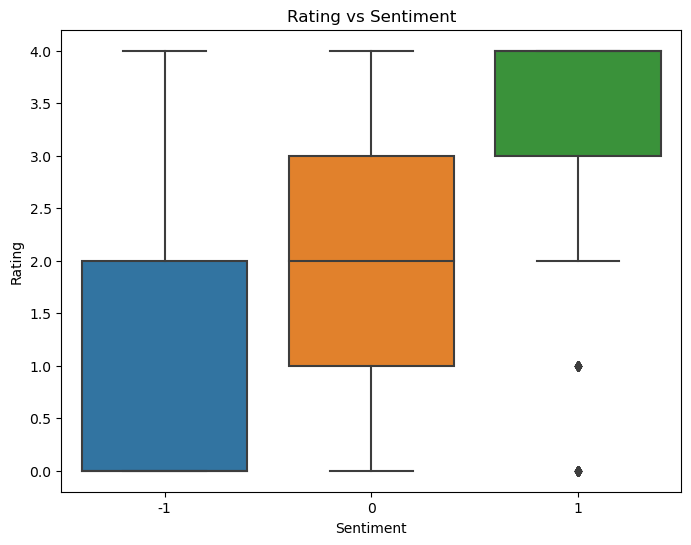

In [24]:

# 1) Rating vs sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sentiment', y='Rate', data=df_subset)
plt.title('Rating vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Rating')
plt.show()





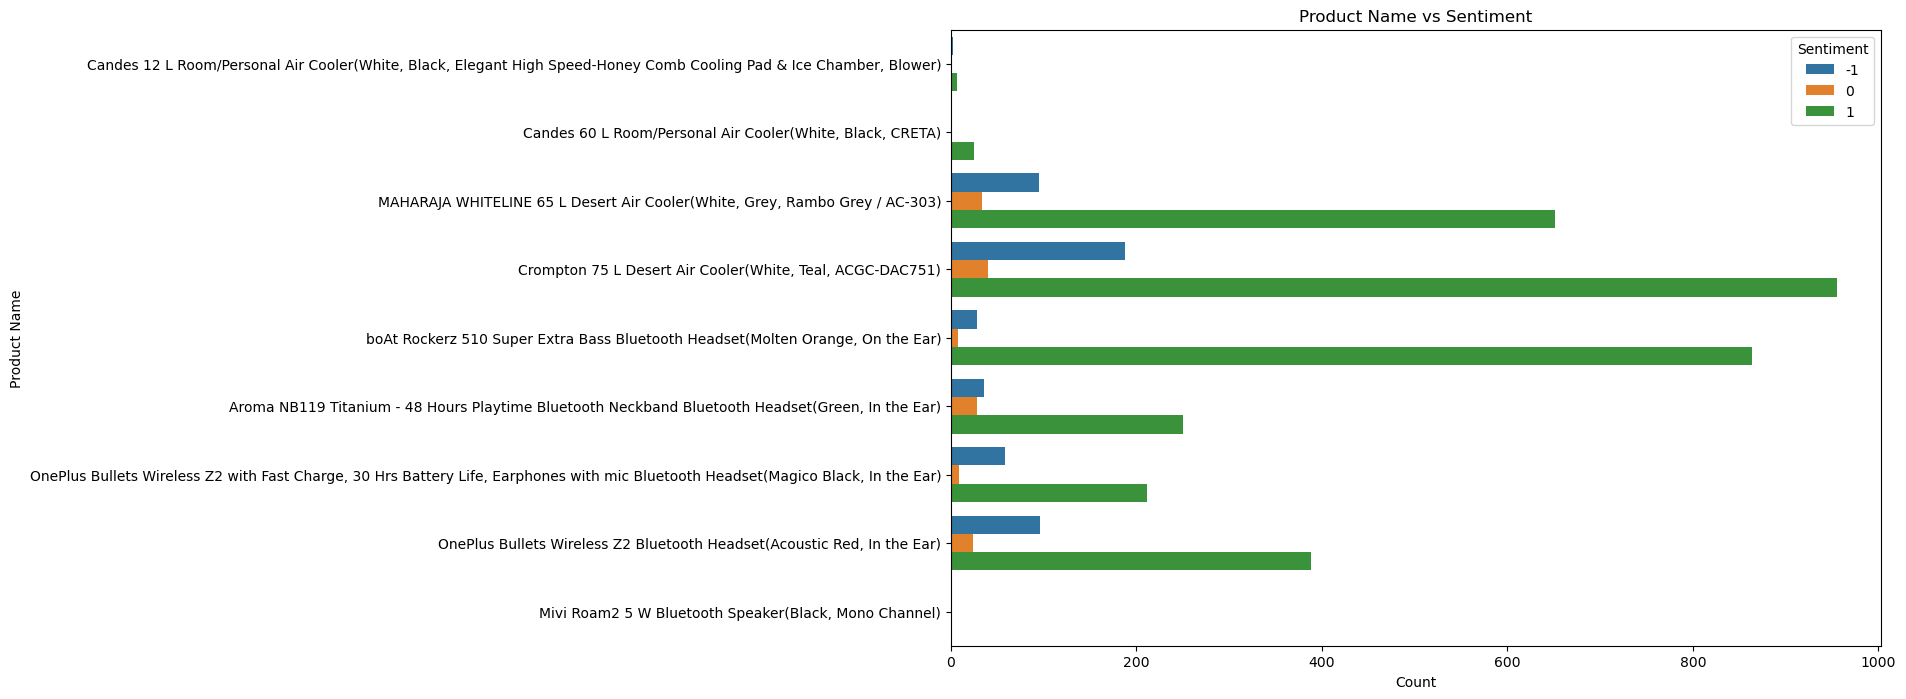

In [21]:

# 2) Product name vs sentiment
plt.figure(figsize=(12, 8))
sns.countplot(y='product_name', hue='Sentiment', data=df_subset)
plt.title('Product Name vs Sentiment')
plt.xlabel('Count')
plt.ylabel('Product Name')
plt.show()


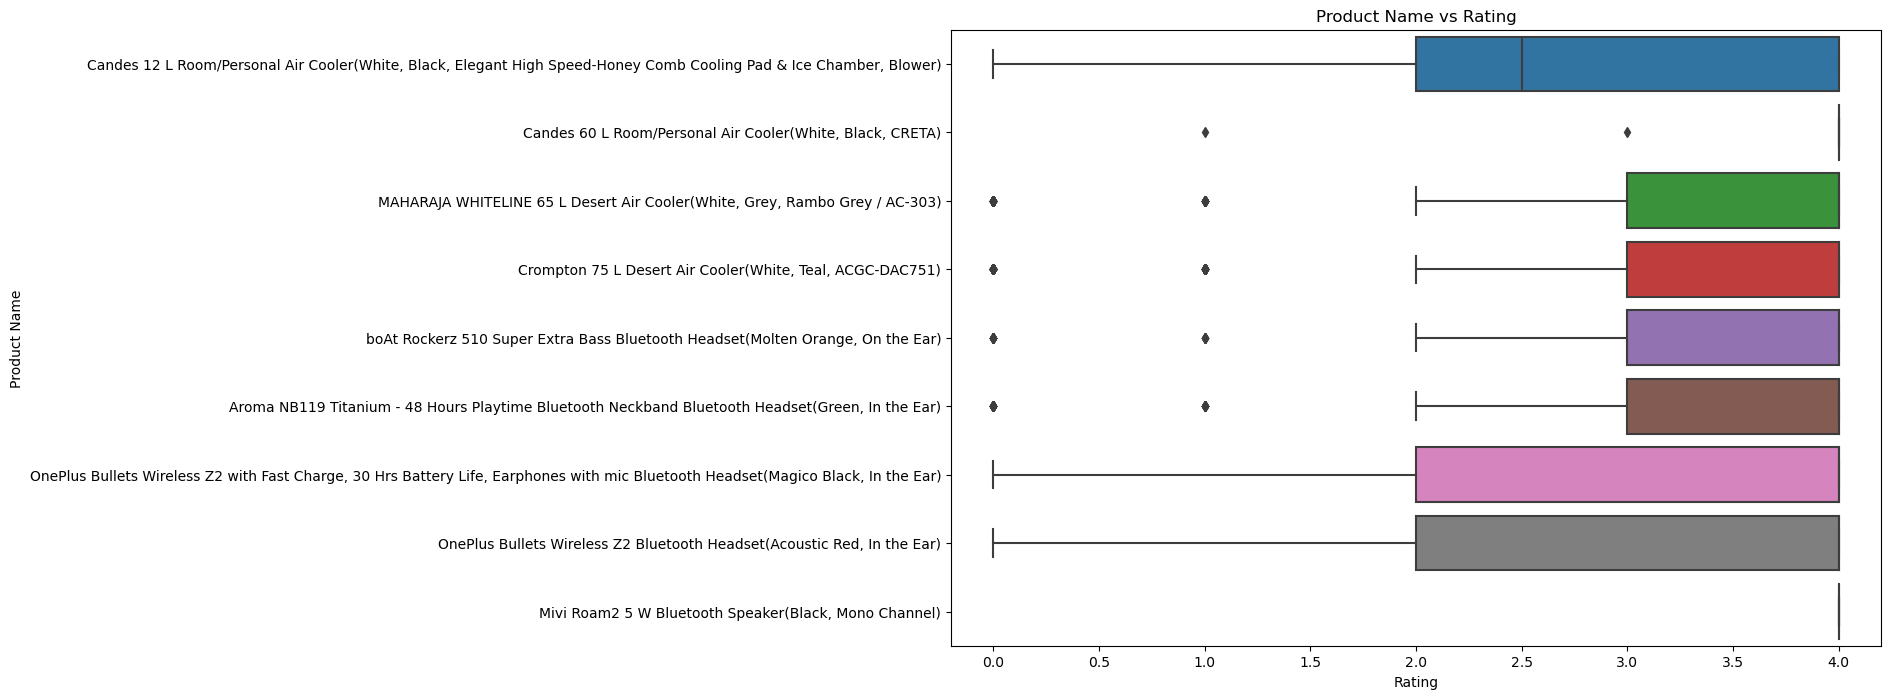

In [22]:
# 3) Product name vs rating
plt.figure(figsize=(12, 8))
sns.boxplot(x='Rate', y='product_name', data=df_subset)
plt.title('Product Name vs Rating')
plt.xlabel('Rating')
plt.ylabel('Product Name')
plt.show()


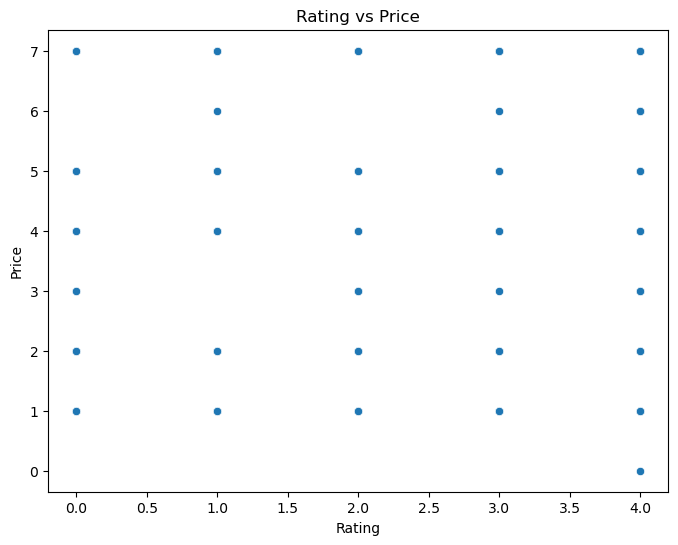

In [23]:
# 4) Rating vs price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Rate', y='product_price', data=df_subset)
plt.title('Rating vs Price')
plt.xlabel('Rating')
plt.ylabel('Price')
plt.show()